# 02 — Choose Bandpass
# Giai đoạn 1 — Mục 1.2/1.3 — Chọn dải bandpass cho envelope
**Đầu ra**: `outputs/tables/bandpass_config.json`

In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import io_utils, dsp, config as cfg

from common.pipeline import pick_file
from common.io_utils import load_de_signal
from common.dsp import compute_fft

In [9]:
OUTPUT_DIR = Path("./outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(TABLES_DIR / "manifest_filtered.csv")

# Vẽ FFT để xác định vùng cộng hưởng

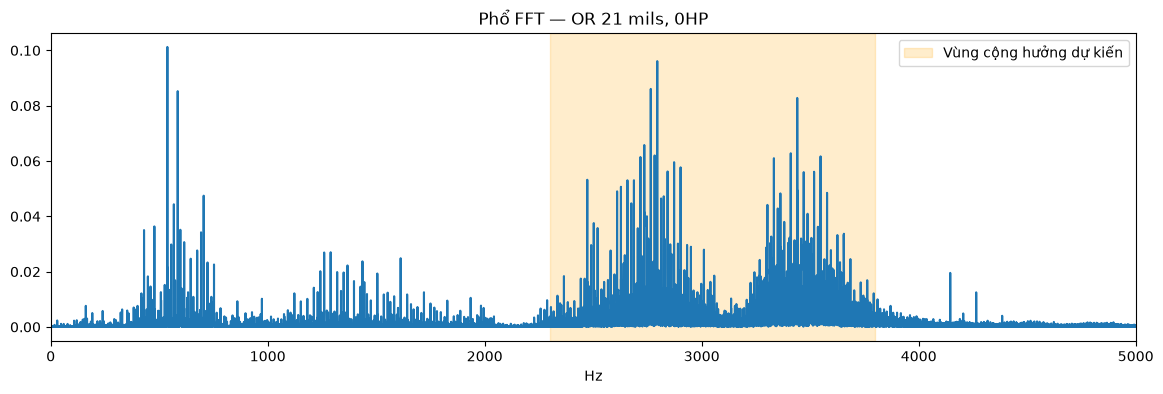

In [14]:
file_path = pick_file(manifest, label="OR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 5000)
plt.title("Phổ FFT — OR 21 mils, 0HP")

plt.axvspan(2300, 3800, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

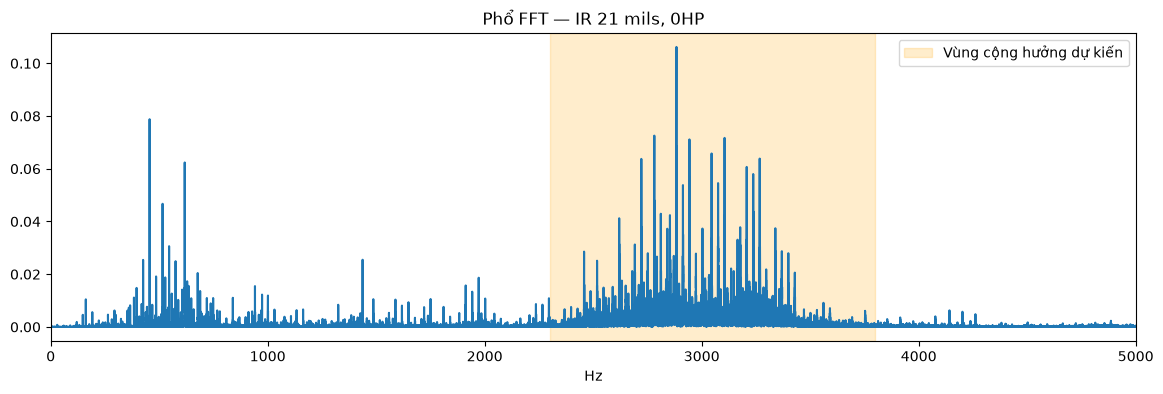

In [16]:
# Chọn 1 file IR lỗi rõ (diam 21 mils, tải 0HP) để quan sát
file_path = pick_file(manifest, label="IR", load_hp=0, diameter_mils=21)
x = load_de_signal(Path(file_path))
fs = 12000

freqs, mag = compute_fft(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs, mag)
plt.xlabel("Hz")
plt.xlim(0, 5000)
plt.title("Phổ FFT — IR 21 mils, 0HP")

plt.axvspan(2300, 3800, alpha=0.2, color='orange', label='Vùng cộng hưởng dự kiến')
plt.legend()

- Chốt bandpass

In [ ]:
BAND_HZ = (2300, 3800)
LP_CUTOFF_HZ = 500

Text(0.5, 1.0, 'Phổ Envelope — Kiểm tra đỉnh BPFO/BPFI/BSF')

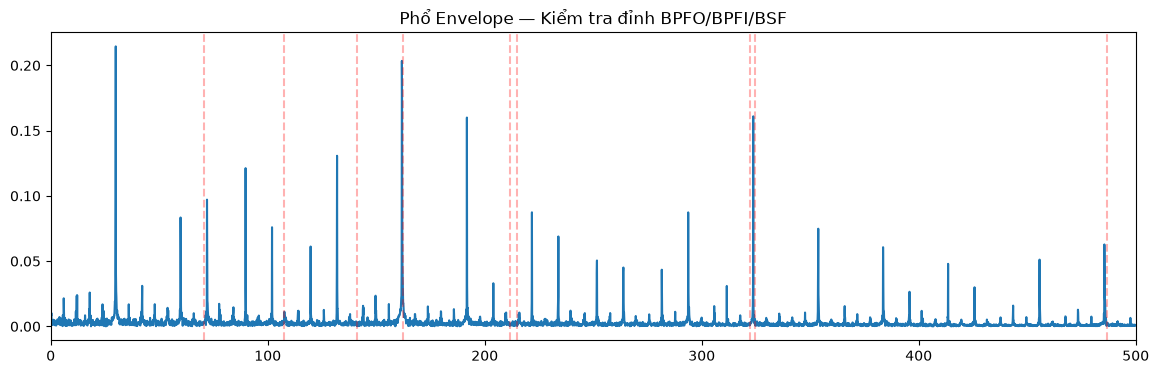

In [17]:
from common.dsp import square_law_envelope
from common.config import bearing_fault_frequencies, NOMINAL_RPM_BY_LOAD

BAND_HZ = (2300, 3800)   # ← điều chỉnh sau khi quan sát
rpm = NOMINAL_RPM_BY_LOAD[0]
fault_freqs = bearing_fault_frequencies(rpm)

env = square_law_envelope(x, fs, band=BAND_HZ, lp_cutoff=500)
freqs_env, mag_env = compute_fft(env - env.mean(), fs)

plt.figure(figsize=(14, 4))
plt.plot(freqs_env, mag_env)
for name in ["BPFO", "BPFI", "BSF"]:
    for h in [1, 2, 3]:
        plt.axvline(fault_freqs[name] * h, color='red', alpha=0.3, linestyle='--')
plt.xlim(0, 500)
plt.title("Phổ Envelope — Kiểm tra đỉnh BPFO/BPFI/BSF")

- LƯU CẤU HÌNH

In [15]:
config = {"band_hz": BAND_HZ, "lp_cutoff_hz": LP_CUTOFF_HZ}
with open(TABLES_DIR / "bandpass_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Đã lưu cấu hình bandpass: {config}")

Đã lưu cấu hình bandpass: {'band_hz': (3200, 3800), 'lp_cutoff_hz': 500}
